In [ ]:
# ===================================================
# 📋 Revealing Hidden Decision Patterns in ML Models
# Replicating: Kauffmann et al. (Nature MI 2025)
# "Explainable AI reveals Clever Hans Effects
#  in Unsupervised Learning Models"
# ===================================================
# Dataset: ImageNet Trucks (8 classes)
# Model: CLIP ResNet-50
# XAI: Grad-CAM (fixed) + BiLRP (fixed) + LRP (new) + CH Mitigation
# Code: cloned from github.com/nhahub/NHA-4-059 (branch: main, under project-root/)
# ===================================================

!pip install -q git+https://github.com/openai/CLIP.git zennit opencv-python-headless

import os
import sys
import torch
import clip
import numpy as np
import pickle
import io
import matplotlib.pyplot as plt
import matplotlib
from PIL import Image, ImageDraw, ImageFont
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from collections import defaultdict
from google.colab import drive

# ربط Drive
drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/rahhala_ch_project'

# ===================================================
# Clone the refactored codebase — the Grad-CAM/BiLRP fixes, LRP, and
# everything else below live in this repo, not duplicated inline here.
# The actual package lives under project-root/ in this repo (alongside the
# notebook, results/, and the SAD/planning docs at repo root).
# ===================================================
REPO_URL = "https://github.com/nhahub/NHA-4-059.git"
REPO_BRANCH = "main"
REPO_DIR = "/content/NHA-4-059"
PACKAGE_DIR = f"{REPO_DIR}/project-root"

if os.path.exists(REPO_DIR):
    !cd {REPO_DIR} && git fetch origin {REPO_BRANCH} && git checkout {REPO_BRANCH} && git pull origin {REPO_BRANCH}
else:
    !git clone --branch {REPO_BRANCH} {REPO_URL} {REPO_DIR}

sys.path.insert(0, PACKAGE_DIR)

from src.models.clip_model import CLIPModel, TRUCK_CLASSES, decode_image
from src.data.image_modifier import ImageModifier
from src.xai.gradcam import GradCAM, overlay_heatmap, attention_alignment_score
from src.xai.bilrp import compute_bilrp, compute_bilrp_naive, plot_bilrp
from src.xai.lrp import LRPExplainer, spatial_correlation
from src.utils.experiment_config import ExperimentConfig, set_seed
from src.utils.experiment_log import ExperimentLogger

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# CLIPModel wraps clip.load + the fp32 fix (see its docstring) + the
# trained classifier in one object — GradCAM/LRPExplainer/ImageModifier
# below are all built to work with it directly.
clip_model = CLIPModel(classifier_path=f'{save_dir}/clf_full.pkl', device=device)

# Keep the original bare names around too — Sections 1-4 below (unchanged)
# still reference them directly.
model = clip_model.model
preprocess = clip_model.preprocess
clf_full = clip_model.classifier
_decode_image = decode_image

# تحميل البيانات المحفوظة
X_train_full = np.load(f'{save_dir}/X_train_full.npy')
y_train_full = np.load(f'{save_dir}/y_train_full.npy')
X_test_full = np.load(f'{save_dir}/X_test_full.npy')
y_test_full = np.load(f'{save_dir}/y_test_full.npy')

with open(f'{save_dir}/truck_samples_test_FULL.pkl', 'rb') as f:
    all_test_examples_full = pickle.load(f)

with open(f'{save_dir}/truck_samples_train_FULL.pkl', 'rb') as f:
    all_train_examples_full = pickle.load(f)

TRUCKS = TRUCK_CLASSES
label_to_name = {v: k for k, v in TRUCKS.items()}

print(f"\nTrain: {X_train_full.shape[0]} samples")
print(f"Test:  {X_test_full.shape[0]} samples")
print(f"Classes: {len(TRUCKS)}")
print(f"Baseline Accuracy: {accuracy_score(y_test_full, clf_full.predict(X_test_full))*100:.2f}%")
print("\n✅ Setup Complete!")

In [6]:
# ===================================================
# 📊 Section 1: Dataset Overview & Class Distribution
# ===================================================

train_counts = {}
test_counts = {}
for label, name in label_to_name.items():
    train_counts[name] = np.sum(y_train_full == label)
    test_counts[name] = np.sum(y_test_full == label)

classes = list(train_counts.keys())
train_vals = [train_counts[c] for c in classes]
test_vals = [test_counts[c] for c in classes]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = plt.cm.Set3(np.linspace(0, 1, 8))
bars1 = axes[0].bar(classes, train_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Training Set Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, train_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
                str(val), ha='center', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(classes, test_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Test Set Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, test_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                str(val), ha='center', fontsize=10, fontweight='bold')

plt.suptitle(f'ImageNet Truck Dataset — {sum(train_vals)} Train / {sum(test_vals)} Test',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/01_dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# عينة صورة من كل كلاس
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for idx, (label, name) in enumerate(sorted(label_to_name.items())):
    ax = axes[idx // 4, idx % 4]
    for ex in all_test_examples_full:
        if ex["label"] == label:
            img = _decode_image(ex["image"])
            ax.imshow(img)
            ax.set_title(name.replace('_', ' ').title(), fontsize=12, fontweight='bold')
            break
    ax.axis('off')

plt.suptitle('Sample Image from Each Truck Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_dir}/02_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Section 1 Complete!")

Output hidden; open in https://colab.research.google.com to view.

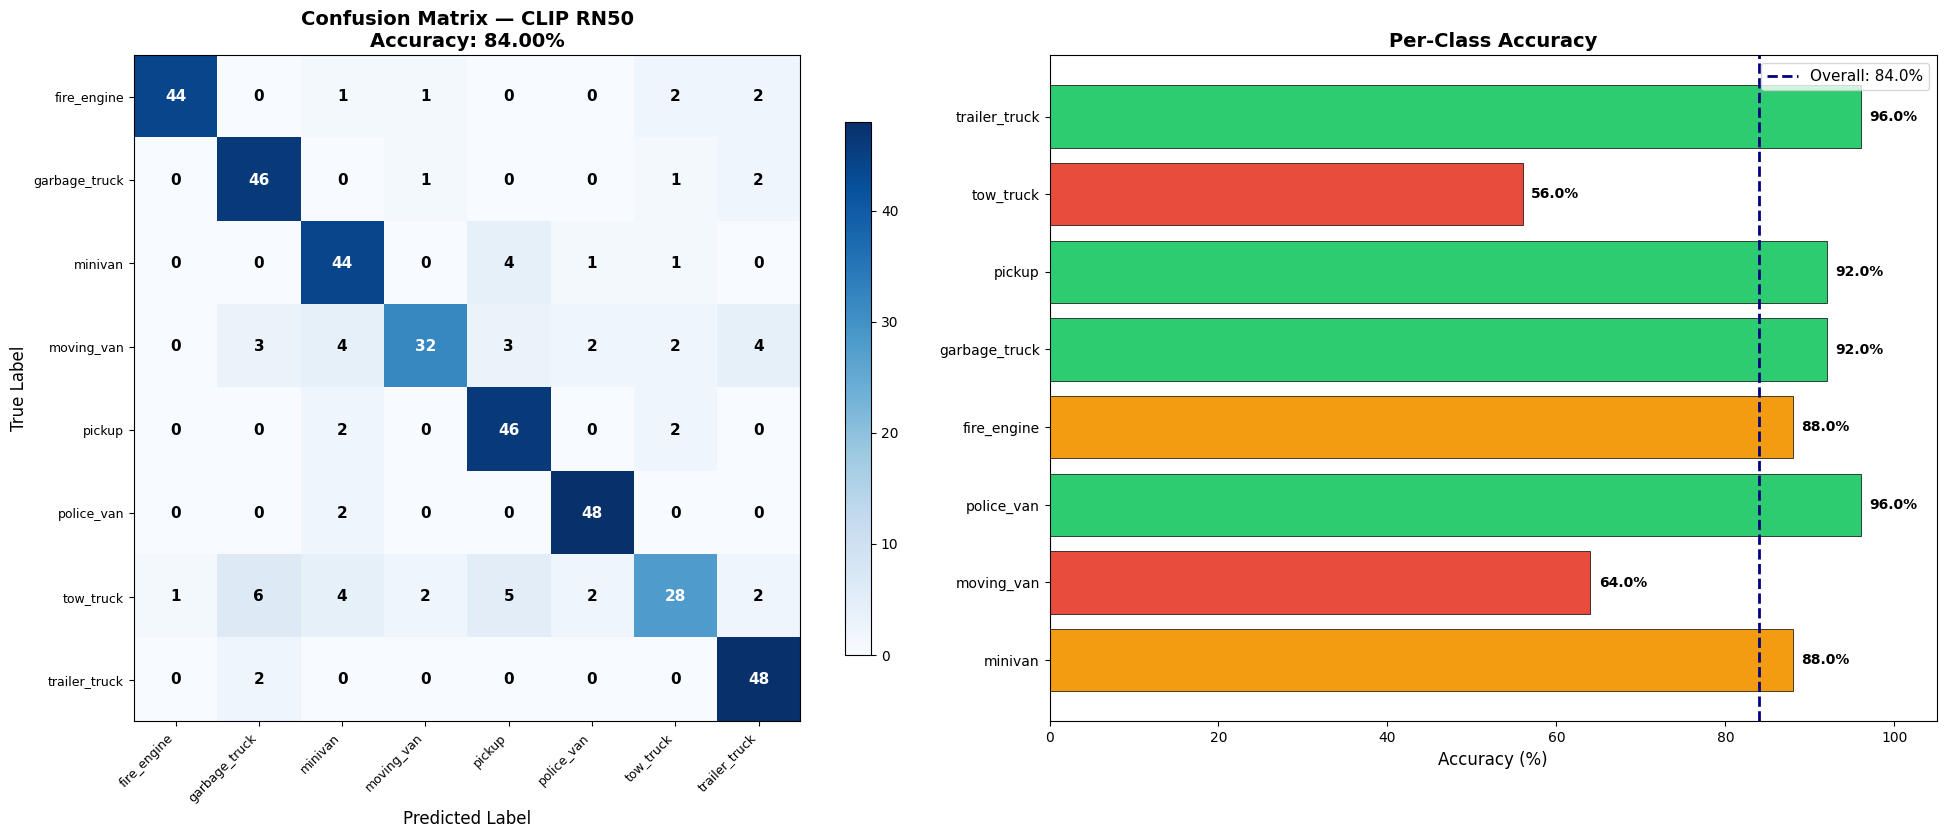


Classification Report — CLIP ResNet-50
               precision    recall  f1-score   support

  fire_engine       0.98      0.88      0.93        50
garbage_truck       0.81      0.92      0.86        50
      minivan       0.77      0.88      0.82        50
   moving_van       0.89      0.64      0.74        50
       pickup       0.79      0.92      0.85        50
   police_van       0.91      0.96      0.93        50
    tow_truck       0.78      0.56      0.65        50
trailer_truck       0.83      0.96      0.89        50

     accuracy                           0.84       400
    macro avg       0.84      0.84      0.83       400
 weighted avg       0.84      0.84      0.83       400

✅ Section 2 Complete!


In [7]:
# ===================================================
# 📊 Section 2: Classification Results & Confusion Matrix
# ===================================================

y_pred = clf_full.predict(X_test_full)
acc = accuracy_score(y_test_full, y_pred)

# Confusion Matrix
class_names = [label_to_name[l] for l in sorted(TRUCKS.values())]
cm = confusion_matrix(y_test_full, y_pred, labels=sorted(TRUCKS.values()))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Confusion Matrix Heatmap
im = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title(f'Confusion Matrix — CLIP RN50\nAccuracy: {acc*100:.2f}%',
                   fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(class_names)))
axes[0].set_yticks(range(len(class_names)))
axes[0].set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(class_names, fontsize=9)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
plt.colorbar(im, ax=axes[0], shrink=0.8)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center',
                    color=color, fontsize=11, fontweight='bold')

# Per-class Accuracy
per_class_acc = {}
for label, name in label_to_name.items():
    mask = y_test_full == label
    if mask.sum() > 0:
        per_class_acc[name] = accuracy_score(y_test_full[mask], y_pred[mask]) * 100

names = list(per_class_acc.keys())
accs = list(per_class_acc.values())
colors_bar = ['#e74c3c' if a < 80 else '#2ecc71' if a > 90 else '#f39c12' for a in accs]

bars = axes[1].barh(names, accs, color=colors_bar, edgecolor='black', linewidth=0.5)
axes[1].set_xlim(0, 105)
axes[1].set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Accuracy (%)', fontsize=12)
axes[1].axvline(x=acc*100, color='navy', linestyle='--', linewidth=2, label=f'Overall: {acc*100:.1f}%')
axes[1].legend(fontsize=11)

for bar, val in zip(bars, accs):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2.,
                f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{save_dir}/03_classification_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print("\n" + "="*60)
print("Classification Report — CLIP ResNet-50")
print("="*60)
report = classification_report(y_test_full, y_pred,
                                labels=sorted(TRUCKS.values()),
                                target_names=class_names)
print(report)
print("✅ Section 2 Complete!")

In [ ]:
# ===================================================
# 🔧 Section 3: Logo Insertion & Clever Hans Detection
# ===================================================
# Uses ImageModifier from the cloned repo (src/data/image_modifier.py)
# instead of a single hardcoded "WASTE MANAGEMENT" logo pasted onto every
# class. paste_logo(img, label=...) picks a fake watermark whose text is
# plausible for that specific truck category (e.g. "CITY FIRE DEPT" for
# fire engines, "RAPID TOWING CO." for tow trucks) — see
# LOGO_TEXT_BY_CATEGORY in image_modifier.py for the full mapping.

modifier = ImageModifier()

# عرض أمثلة: قبل وبعد اللوجو
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
sample_classes = [555, 569, 717, 867]  # fire_engine, garbage_truck, pickup, trailer_truck
sample_names = ["Fire Engine", "Garbage Truck", "Pickup", "Trailer Truck"]

for i, (cls, name) in enumerate(zip(sample_classes, sample_names)):
    for ex in all_test_examples_full:
        if ex["label"] == cls:
            img = _decode_image(ex["image"])
            img_logo = modifier.paste_logo(img.copy(), label=cls)
            axes[0, i].imshow(img)
            axes[0, i].set_title(f'{name} — Original', fontsize=11, fontweight='bold')
            axes[0, i].axis('off')
            axes[1, i].imshow(img_logo)
            axes[1, i].set_title(f'{name} — With Logo', fontsize=11, fontweight='bold')
            axes[1, i].axis('off')
            break

plt.suptitle('Logo Insertion: Original vs Modified Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_dir}/04_logo_insertion_examples.png', dpi=150, bbox_inches='tight')
plt.show()

# استخراج features باللوجو
print("Extracting features with logo...")
features_logo = []
labels_logo = []

with torch.no_grad():
    for example in tqdm(all_test_examples_full, desc="Logo Features"):
        img = _decode_image(example["image"])
        img_logo = modifier.paste_logo(img, label=example["label"])
        img_input = preprocess(img_logo).unsqueeze(0).to(device)
        feat = model.encode_image(img_input)
        feat = feat.cpu().numpy().flatten()
        features_logo.append(feat)
        labels_logo.append(example["label"])

X_test_logo = np.array(features_logo)
y_test_logo = np.array(labels_logo)

y_pred_logo = clf_full.predict(X_test_logo)
acc_logo = accuracy_score(y_test_logo, y_pred_logo)

# مقارنة الأرقام: Original vs Logo
per_class_orig = {}
per_class_logo = {}
for label, name in label_to_name.items():
    mask = y_test_full == label
    per_class_orig[name] = accuracy_score(y_test_full[mask], y_pred[mask]) * 100
    per_class_logo[name] = accuracy_score(y_test_logo[mask], y_pred_logo[mask]) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Bar chart مقارنة
names = list(per_class_orig.keys())
orig_vals = [per_class_orig[n] for n in names]
logo_vals = [per_class_logo[n] for n in names]

x = np.arange(len(names))
width = 0.35

bars1 = axes[0].bar(x - width/2, orig_vals, width, label='Original', color='#3498db', edgecolor='black')
bars2 = axes[0].bar(x + width/2, logo_vals, width, label='+ Logo', color='#e74c3c', edgecolor='black')
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Per-Class Accuracy: Original vs Logo', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=9)
axes[0].legend(fontsize=12)
axes[0].set_ylim(0, 105)
axes[0].axhline(y=acc*100, color='#3498db', linestyle='--', alpha=0.5)
axes[0].axhline(y=acc_logo*100, color='#e74c3c', linestyle='--', alpha=0.5)

# Performance Delta
deltas = [logo_vals[i] - orig_vals[i] for i in range(len(names))]
colors_delta = ['#e74c3c' if d < 0 else '#2ecc71' for d in deltas]
axes[1].barh(names, deltas, color=colors_delta, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Accuracy Change (%)', fontsize=12)
axes[1].set_title(f'Performance Delta (Logo - Original)\nOverall: {acc*100:.1f}% → {acc_logo*100:.1f}%',
                   fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=1)

for i, (val, name) in enumerate(zip(deltas, names)):
    axes[1].text(val + (0.5 if val >= 0 else -0.5), i,
                f'{val:+.1f}%', va='center', fontsize=10, fontweight='bold',
                ha='left' if val >= 0 else 'right')

plt.tight_layout()
plt.savefig(f'{save_dir}/05_logo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOriginal Accuracy: {acc*100:.2f}%")
print(f"Logo Accuracy:     {acc_logo*100:.2f}%")
print(f"Delta:             {(acc_logo-acc)*100:+.2f}%")
print("✅ Section 3 Complete!")

In [ ]:
# ===================================================
# 🛠️ Section 4: CH Mitigation + Final Results
# ===================================================

# حساب filter indices
hook_output = {}
def hook_fn(module, input, output):
    hook_output['act'] = output.detach().cpu()

for name, module in model.visual.named_modules():
    if name == 'relu3':
        handle = module.register_forward_hook(hook_fn)
        break

act_diffs = []
sample_size = min(200, len(all_test_examples_full))

with torch.no_grad():
    for i in tqdm(range(sample_size), desc="Computing filter diffs"):
        example = all_test_examples_full[i]
        img_clean = _decode_image(example["image"])
        inp_clean = preprocess(img_clean).unsqueeze(0).to(device)
        model.encode_image(inp_clean)
        act_clean = hook_output['act'].numpy()

        # label=example["label"]: this class's own fake watermark text
        # (via the `modifier` built in Section 3), not one fixed logo.
        img_logo = modifier.paste_logo(img_clean, label=example["label"])
        inp_logo = preprocess(img_logo).unsqueeze(0).to(device)
        model.encode_image(inp_logo)
        act_logo = hook_output['act'].numpy()

        diff = np.abs(act_logo - act_clean).mean(axis=(0, 2, 3))
        act_diffs.append(diff)

handle.remove()

avg_diffs = np.mean(act_diffs, axis=0)
filter_indices = np.argsort(avg_diffs)
top5 = filter_indices[-5:]
print(f"Top 5 Clever Hans filters: {top5}")

# تطبيق CH Fix
def clip_fix(model, module_name='relu3', num_filters=5, y_offset=90):
    def hook(model, input, output):
        mask = torch.ones_like(output)
        ind = filter_indices[-num_filters:]
        for f in ind:
            mask[:, f, y_offset:, :] = 0
        return output * mask

    for n, m in model.visual.named_modules():
        if n == module_name:
            m.register_forward_hook(hook)
            break
    return model

model_fixed = clip_fix(model, num_filters=5)

# استخراج features بالموديل المعدّل
print("Extracting fixed features (test original)...")
feat_fixed, lab_fixed = [], []
with torch.no_grad():
    for ex in tqdm(all_test_examples_full, desc="CH Fix - Test"):
        img = _decode_image(ex["image"])
        inp = preprocess(img).unsqueeze(0).to(device)
        f = model_fixed.encode_image(inp).cpu().numpy().flatten()
        feat_fixed.append(f)
        lab_fixed.append(ex["label"])

X_fix = np.array(feat_fixed)
y_fix = np.array(lab_fixed)

print("Extracting fixed features (test + logo)...")
feat_fix_logo, lab_fix_logo = [], []
with torch.no_grad():
    for ex in tqdm(all_test_examples_full, desc="CH Fix - Logo"):
        img = _decode_image(ex["image"])
        img_l = modifier.paste_logo(img, label=ex["label"])
        inp = preprocess(img_l).unsqueeze(0).to(device)
        f = model_fixed.encode_image(inp).cpu().numpy().flatten()
        feat_fix_logo.append(f)
        lab_fix_logo.append(ex["label"])

X_fix_logo = np.array(feat_fix_logo)
y_fix_logo = np.array(lab_fix_logo)

print("Extracting fixed features (train)...")
feat_train_fix, lab_train_fix = [], []
with torch.no_grad():
    for ex in tqdm(all_train_examples_full, desc="CH Fix - Train"):
        img = _decode_image(ex["image"])
        inp = preprocess(img).unsqueeze(0).to(device)
        f = model_fixed.encode_image(inp).cpu().numpy().flatten()
        feat_train_fix.append(f)
        lab_train_fix.append(ex["label"])

X_train_fix = np.array(feat_train_fix)
y_train_fix = np.array(lab_train_fix)

clf_fix = LogisticRegression(max_iter=3000, C=1.0)
clf_fix.fit(X_train_fix, y_train_fix)

acc_fix_orig = accuracy_score(y_fix, clf_fix.predict(X_fix))
acc_fix_logo = accuracy_score(y_fix_logo, clf_fix.predict(X_fix_logo))

# ===================================================
# 📊 Final Results Table
# ===================================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table_data = [
    ['Experiment', 'Test Accuracy', 'Observation'],
    ['CLIP Original', f'{acc*100:.2f}%', 'Baseline performance'],
    ['CLIP + Logo Inserted', f'{acc_logo*100:.2f}%', f'Drop of {(acc-acc_logo)*100:.2f}% — CH detected'],
    ['CH Mitigation (Clean)', f'{acc_fix_orig*100:.2f}%', 'Performance after removing shortcut filters'],
    ['CH Mitigation (+ Logo)', f'{acc_fix_logo*100:.2f}%', 'Model now robust to logo insertion'],
]

colors_table = [['#2c3e50']*3] + [['#e8f8e8']*3, ['#fce4e4']*3, ['#e8f4fd']*3, ['#e8f4fd']*3]

table = ax.table(cellText=table_data, cellColours=colors_table, cellLoc='center',
                 loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(12)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('white')
    cell.set_linewidth(2)
    if row == 0:
        cell.set_text_props(fontweight='bold', color='white')
        cell.set_height(0.15)
    else:
        cell.set_text_props(color='black')
        cell.set_height(0.15)

ax.set_title('Clever Hans Detection & Mitigation — Summary of Results',
             fontsize=16, fontweight='bold', pad=20)

plt.savefig(f'{save_dir}/06_final_results_table.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart نهائي
fig, ax = plt.subplots(figsize=(10, 6))
conditions = ['Original', '+ Logo\n(CH Test)', 'CH Fix\n(Clean)', 'CH Fix\n(+ Logo)']
our_vals = [acc*100, acc_logo*100, acc_fix_orig*100, acc_fix_logo*100]
bar_colors = ['#3498db', '#e74c3c', '#2ecc71', '#27ae60']

bars = ax.bar(conditions, our_vals, color=bar_colors, edgecolor='black', linewidth=0.8, width=0.6)

ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('CLIP ResNet-50 — Clever Hans Detection & Mitigation Pipeline',
             fontsize=15, fontweight='bold')
ax.set_ylim(70, 90)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.2f}%', ha='center', fontsize=12, fontweight='bold')

# سهم بيوضح الـ drop
ax.annotate('', xy=(1, acc_logo*100), xytext=(0, acc*100),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(0.5, (acc*100 + acc_logo*100)/2 + 0.5, f'−{(acc-acc_logo)*100:.2f}%',
        ha='center', fontsize=11, color='red', fontweight='bold')

# سهم بيوضح الـ recovery
ax.annotate('', xy=(2, acc_fix_orig*100), xytext=(1, acc_logo*100),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(1.5, (acc_logo*100 + acc_fix_orig*100)/2 + 0.5, f'+{(acc_fix_orig-acc_logo)*100:.2f}%',
        ha='center', fontsize=11, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{save_dir}/07_final_pipeline_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*50}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*50}")
print(f"CLIP Original:       {acc*100:.2f}%")
print(f"CLIP + Logo:         {acc_logo*100:.2f}%")
print(f"CH Fix (Original):   {acc_fix_orig*100:.2f}%")
print(f"CH Fix (+ Logo):     {acc_fix_logo*100:.2f}%")
print(f"{'='*50}")
print("✅ Section 4 Complete!")

In [ ]:
# ===================================================
# 🔬 Section 5: Explainable AI — Grad-CAM Analysis
# ===================================================
# Uses GradCAM from the cloned repo (src/xai/gradcam.py). It already fixes
# the original bug: this used to backprop from
# features[0, features[0].argmax()] — an arbitrary raw CLIP-embedding
# coordinate with no connection to the truck-classifier's actual decision,
# which is why heatmaps used to light up an unrelated corner instead of
# the planted logo. GradCAM now backprops from clf_full's own
# decision-function logit for the predicted class (w_c . features + b_c).

gradcam = GradCAM(clip_model)
modifier = ImageModifier()

def get_gradcam(img, class_index=None):
    """Thin wrapper matching this notebook's original (cam, predicted_label)
    call signature — GradCAM itself returns (cam, class_index_in_clf)."""
    cam, class_index = gradcam(img, class_index_in_clf=class_index)
    predicted_label = clf_full.classes_[class_index]
    return cam, predicted_label

# ===================================================
# 5A: Grad-CAM على كل الكلاسات
# ===================================================
fig, axes = plt.subplots(2, 8, figsize=(28, 7))
for idx, (label, name) in enumerate(sorted(label_to_name.items())):
    for ex in all_test_examples_full:
        if ex["label"] == label:
            img = _decode_image(ex["image"]).resize((224, 224))
            cam, pred_label = get_gradcam(img)
            score = attention_alignment_score(cam, modifier.logo_regions(img))

            axes[0, idx].imshow(img)
            axes[0, idx].set_title(name.replace('_', ' ').title(), fontsize=10, fontweight='bold')
            axes[0, idx].axis('off')

            axes[1, idx].imshow(img)
            axes[1, idx].imshow(cam, cmap='jet', alpha=0.5)
            axes[1, idx].set_title(f'Grad-CAM (logo focus: {score:.0%})', fontsize=9)
            axes[1, idx].axis('off')
            break
    print(f"  {name} done")

plt.suptitle('Grad-CAM Analysis — Where Does CLIP Focus for Each Truck Class?\n'
             '(these are CLEAN images with no logo — "logo focus %" should be low here)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_dir}/08_gradcam_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()

# ===================================================
# 5B: Grad-CAM مقارنة — قبل وبعد اللوجو
# ===================================================
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
sample_labels = [717, 555, 867]  # pickup, fire_engine, trailer_truck
sample_names_5b = ["Pickup", "Fire Engine", "Trailer Truck"]

for i, (cls, name) in enumerate(zip(sample_labels, sample_names_5b)):
    for ex in all_test_examples_full:
        if ex["label"] == cls:
            img = _decode_image(ex["image"]).resize((224, 224))
            # label=cls: use this class's own fake watermark text (e.g. "CITY FIRE
            # DEPT" for fire engines) instead of the same "WASTE MANAGEMENT" text
            # pasted onto every category regardless of what's actually in frame.
            img_logo = modifier.paste_logo(_decode_image(ex["image"]), label=cls).resize((224, 224))

            cam_orig, _ = get_gradcam(img)
            cam_logo, _ = get_gradcam(img_logo)
            score_orig = attention_alignment_score(cam_orig, modifier.logo_regions(img))
            score_logo = attention_alignment_score(cam_logo, modifier.logo_regions(img_logo))

            axes[i, 0].imshow(img)
            axes[i, 0].set_title(f'{name} — Original', fontsize=11, fontweight='bold')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(img)
            axes[i, 1].imshow(cam_orig, cmap='jet', alpha=0.5)
            axes[i, 1].set_title(f'Grad-CAM (logo focus: {score_orig:.0%})', fontsize=11)
            axes[i, 1].axis('off')

            axes[i, 2].imshow(img_logo)
            axes[i, 2].set_title(f'{name} — With Logo', fontsize=11, fontweight='bold')
            axes[i, 2].axis('off')

            axes[i, 3].imshow(img_logo)
            axes[i, 3].imshow(cam_logo, cmap='jet', alpha=0.5)
            axes[i, 3].set_title(f'Grad-CAM (logo focus: {score_logo:.0%})', fontsize=11)
            axes[i, 3].axis('off')

            flag = "  <-- FLAGGED: >30% attention on logo (Clever Hans)" if score_logo > 0.30 else ""
            print(f"  {name}: logo focus {score_orig:.1%} -> {score_logo:.1%}{flag}")
            break

plt.suptitle('Clever Hans Effect Visualized: Attention Shift After Logo Insertion',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_dir}/09_gradcam_logo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ===================================================
# 5C: BiLRP — Pairwise Feature Attribution
# ===================================================
# compute_bilrp (src/xai/bilrp.py) is the FIX: a true joint (mixed
# second-derivative) attribution. The original notebook's method
# (compute_bilrp_naive, kept for comparison) computed two INDEPENDENT
# per-image gradient-saliency maps and took their outer product — which
# draws a strong line between any two individually high-gradient patches
# regardless of whether the model relates them at all.
print("\nComputing BiLRP visualizations...")

garbage_imgs = [ex for ex in all_test_examples_full if ex["label"] == 569]
img_g1 = _decode_image(garbage_imgs[0]["image"])
img_g2 = _decode_image(garbage_imgs[1]["image"])
R_g, sim_g = compute_bilrp(clip_model, img_g1, img_g2)
plot_bilrp(img_g1, img_g2, R_g, sim_g,
           title="BiLRP (fixed, joint attribution): Garbage Truck ↔ Garbage Truck",
           fname=f'{save_dir}/10_bilrp_garbage.png', show=True)
print(f"  Garbage Truck pair similarity: {sim_g:.4f}")

pickup_imgs = [ex for ex in all_test_examples_full if ex["label"] == 717]
img_p1 = _decode_image(pickup_imgs[0]["image"])
img_p2 = _decode_image(pickup_imgs[1]["image"])
R_p, sim_p = compute_bilrp(clip_model, img_p1, img_p2)
plot_bilrp(img_p1, img_p2, R_p, sim_p,
           title="BiLRP (fixed, joint attribution): Pickup ↔ Pickup",
           fname=f'{save_dir}/11_bilrp_pickup.png', show=True)
print(f"  Pickup pair similarity: {sim_p:.4f}")

img_p3 = _decode_image(pickup_imgs[2]["image"])
img_p3_logo = modifier.paste_logo(img_p3.copy(), label=717)  # pickup's own logo text
R_l, sim_l = compute_bilrp(clip_model, img_p3, img_p3_logo)
plot_bilrp(img_p3, img_p3_logo, R_l, sim_l,
           title="BiLRP (fixed, joint attribution): Original ↔ Same Image + Logo",
           fname=f'{save_dir}/12_bilrp_logo_shift.png', show=True)
print(f"  Original vs Logo similarity: {sim_l:.4f}")

# Side-by-side: naive (buggy) vs fixed, on the same garbage-truck pair, so
# the difference the fix makes is directly visible.
R_g_naive, sim_g_naive = compute_bilrp_naive(clip_model, img_g1, img_g2)
plot_bilrp(img_g1, img_g2, R_g_naive, sim_g_naive,
           title="BiLRP (ORIGINAL/naive outer-product — for comparison only): Garbage Truck ↔ Garbage Truck",
           fname=f'{save_dir}/10b_bilrp_garbage_naive_comparison.png', show=True)

print("\n✅ Section 5 Complete!")

In [ ]:
# ===================================================
# 🔬 Section 5D: Layer-wise Relevance Propagation (LRP) via Zennit — NEW
# ===================================================
# FR-4 (optional LRP) + FR-7 (Grad-CAM vs LRP spatial correlation).
# Uses LRPExplainer from the cloned repo (src/xai/lrp.py) — see that
# file's docstring for why CLIP RN50's AttentionPool2d falls back to plain
# gradient (it's a single custom attention call, not a chain of hookable
# submodules), while every conv/batchnorm/relu layer before it still gets
# a true LRP rule.

lrp = LRPExplainer(clip_model)

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
sample_labels_5d = [717, 555, 867]  # pickup, fire_engine, trailer_truck
sample_names_5d = ["Pickup", "Fire Engine", "Trailer Truck"]

for i, (cls, name) in enumerate(zip(sample_labels_5d, sample_names_5d)):
    for ex in all_test_examples_full:
        if ex["label"] == cls:
            # label=cls: this class's own fake watermark text, not the same
            # "WASTE MANAGEMENT" text on every category.
            img_logo = modifier.paste_logo(_decode_image(ex["image"]), label=cls).resize((224, 224))

            cam_gradcam, class_idx = gradcam(img_logo)
            # explain the SAME predicted class with LRP, for a fair comparison
            cam_lrp, _ = lrp(img_logo, class_index_in_clf=class_idx)

            corr = spatial_correlation(cam_gradcam, cam_lrp)

            axes[i, 0].imshow(img_logo)
            axes[i, 0].set_title(f'{name} + Logo', fontsize=11, fontweight='bold')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(img_logo)
            axes[i, 1].imshow(cam_gradcam, cmap='jet', alpha=0.5)
            axes[i, 1].set_title('Grad-CAM', fontsize=11)
            axes[i, 1].axis('off')

            axes[i, 2].imshow(img_logo)
            axes[i, 2].imshow(cam_lrp, cmap='jet', alpha=0.5)
            axes[i, 2].set_title('LRP (Zennit)', fontsize=11)
            axes[i, 2].axis('off')

            axes[i, 3].axis('off')
            axes[i, 3].text(0.5, 0.5, f'Spatial correlation:\n{corr:.3f}',
                             ha='center', va='center', fontsize=16, fontweight='bold',
                             transform=axes[i, 3].transAxes)
            print(f"  {name}: Grad-CAM vs LRP spatial correlation = {corr:.4f}")
            break

plt.suptitle('FR-7: Grad-CAM vs LRP Comparison (+ Logo images)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_dir}/13_gradcam_vs_lrp.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Section 5D Complete!")

In [ ]:
# ===================================================
# 💾 Section 5E: Batch Metrics Export — NEW (FR-5, FR-7, FR-8)
# ===================================================
# Uses ExperimentConfig/ExperimentLogger from the cloned repo
# (src/utils/) instead of hand-rolled JSON/CSV writing.
#
# Produces:
#   experiment_config.json      FR-8: seed + what was run, so this is reproducible
#   energy_ratio_all.csv        FR-5 Attention Alignment Score, ALL test images (clean + logo)
#   spurious_flags.csv          FR-5: rows where >30% attention falls on the logo
#   gradcam_lrp_correlation.csv FR-7, on a per-class sample (LRP is an extra backward pass/image)
#   experiment_log.csv          one appended row summarizing this run

import pandas as pd

config = ExperimentConfig(
    classifier_path=f'{save_dir}/clf_full.pkl',
    examples_path=f'{save_dir}/truck_samples_test_FULL.pkl',
    methods=["clean", "logo"],
    output_dir=save_dir,
    seed=42,
    notes="Colab validation run of the Grad-CAM/BiLRP/LRP fixes",
)
config.save(f'{save_dir}/experiment_config.json')
set_seed(config.seed)
print(f"Saved experiment config to {save_dir}/experiment_config.json")

LRP_SAMPLE_PER_CLASS = 5  # keep small: LRP is a full extra backward pass per image

# --- Attention Alignment Score, over every clean + logo test image ---
energy_rows = []
for ex in tqdm(all_test_examples_full, desc="Alignment score [clean+logo, all test images]"):
    img_clean = _decode_image(ex["image"]).resize((224, 224))
    # label=ex["label"]: each image gets its own category's fake watermark
    # text instead of the same "WASTE MANAGEMENT" text for every class.
    img_logo = modifier.paste_logo(_decode_image(ex["image"]), label=ex["label"]).resize((224, 224))

    cam_clean, _ = gradcam(img_clean)
    cam_logo, _ = gradcam(img_logo)

    fname = ex.get("filename", f"{label_to_name[ex['label']]}_{id(ex)}.jpg")
    energy_rows.append({
        "filename": fname, "class": label_to_name[ex["label"]], "method": "clean",
        "energy_ratio": round(attention_alignment_score(cam_clean, modifier.logo_regions(img_clean)), 4),
    })
    energy_rows.append({
        "filename": fname, "class": label_to_name[ex["label"]], "method": "logo",
        "energy_ratio": round(attention_alignment_score(cam_logo, modifier.logo_regions(img_logo)), 4),
    })

energy_df = pd.DataFrame(energy_rows)
energy_path = f'{save_dir}/energy_ratio_all.csv'
energy_df.to_csv(energy_path, index=False)
print(f"Wrote {energy_path} ({len(energy_df)} rows)")

flagged_df = energy_df[energy_df["energy_ratio"] > 0.30]
flagged_path = f'{save_dir}/spurious_flags.csv'
flagged_df.to_csv(flagged_path, index=False)
print(f"Wrote {flagged_path} ({len(flagged_df)} rows flagged >30% logo attention)")

mean_clean = energy_df[energy_df.method == "clean"]["energy_ratio"].mean()
mean_logo = energy_df[energy_df.method == "logo"]["energy_ratio"].mean()
print(f"\nMean logo-region attention — clean: {mean_clean:.1%}, with logo: {mean_logo:.1%}")
print("(if the Grad-CAM fix worked, 'with logo' should be substantially higher than 'clean')")

# --- Grad-CAM vs LRP correlation, on a small per-class sample ---
corr_rows = []
examples_by_class = defaultdict(list)
for ex in all_test_examples_full:
    examples_by_class[ex["label"]].append(ex)

for label, name in label_to_name.items():
    sample = examples_by_class[label][:LRP_SAMPLE_PER_CLASS]
    for ex in tqdm(sample, desc=f"Grad-CAM vs LRP [{name}]"):
        img_logo = modifier.paste_logo(_decode_image(ex["image"]), label=label).resize((224, 224))
        cam_gradcam, class_idx = gradcam(img_logo)
        cam_lrp, _ = lrp(img_logo, class_index_in_clf=class_idx)
        corr = spatial_correlation(cam_gradcam, cam_lrp)
        corr_rows.append({
            "filename": ex.get("filename", f"{name}_{id(ex)}.jpg"),
            "class": name,
            "method": "logo",
            "spatial_correlation": round(corr, 4),
            "gradcam_energy_ratio": round(attention_alignment_score(cam_gradcam, modifier.logo_regions(img_logo)), 4),
            "lrp_energy_ratio": round(attention_alignment_score(cam_lrp, modifier.logo_regions(img_logo)), 4),
        })

corr_df = pd.DataFrame(corr_rows)
corr_path = f'{save_dir}/gradcam_lrp_correlation.csv'
corr_df.to_csv(corr_path, index=False)
print(f"\nWrote {corr_path} ({len(corr_df)} rows)")
print(f"Mean Grad-CAM vs LRP spatial correlation: {corr_df['spatial_correlation'].mean():.4f}")

# --- FR-8: experiment log ---
logger = ExperimentLogger(f'{save_dir}/experiment_log.csv')
exp_id = logger.log(
    model_name="CLIP-RN50",
    dataset_id="imagenet_trucks",
    xai_method="gradcam_vs_lrp",
    accuracy=float(acc),
    focus_score=float(mean_logo),
    shortcut_detected=bool(len(flagged_df) > 0),
    heatmap_path=save_dir,
    notes=config.notes,
)
print(f"Logged experiment {exp_id} to {save_dir}/experiment_log.csv")

print("\n✅ Section 5E Complete — CSV artifacts written to", save_dir)

In [ ]:
# ===================================================
# 🔬 Section 5F: Early-Layer Grad-CAM — Checking the Paper's Own Layer Choice
# ===================================================
# Kauffmann et al. (the paper this notebook replicates) found the CLIP-logo
# signal concentrated in an EARLY stem layer (their Methods: CH mitigation
# uses `encoder.relu3` because "it showed a large difference on just a few
# filters compared to more abstract layers later in the network"). Section 5
# above targets the LAST residual block instead (the deepest, most abstract
# layer) — if the logo signal really lives in the early stem and gets
# abstracted away by the final layer, that alone explains the ~0% logo focus
# seen in 5B/5E, without the CH-effect hypothesis itself being wrong.
#
# GradCAM.__init__ already accepts target_layer_name, so this needs no new
# code in src/ — just pointing it at an earlier layer. We use `bn3` (the
# batchnorm right before relu3, same spatial resolution/semantics) instead
# of `relu3` itself: relu3 is `nn.ReLU(inplace=True)`, and hooking an
# in-place ReLU directly with register_full_backward_hook is a known-flaky
# PyTorch pattern (can raise in-place-modification errors). Grad-CAM's own
# final ReLU already handles positivity, so pre-activation bn3 is an
# equivalent, safer stand-in for "the early stem output the paper analyzes".

gradcam_early = GradCAM(clip_model, target_layer_name='bn3')

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
sample_labels_5f = [717, 555, 867]  # pickup, fire_engine, trailer_truck
sample_names_5f = ["Pickup", "Fire Engine", "Trailer Truck"]

for i, (cls, name) in enumerate(zip(sample_labels_5f, sample_names_5f)):
    for ex in all_test_examples_full:
        if ex["label"] == cls:
            img = _decode_image(ex["image"]).resize((224, 224))
            img_logo = modifier.paste_logo(_decode_image(ex["image"]), label=cls).resize((224, 224))

            cam_orig_early, _ = gradcam_early(img)
            cam_logo_early, _ = gradcam_early(img_logo)
            score_orig_early = attention_alignment_score(cam_orig_early, modifier.logo_regions(img))
            score_logo_early = attention_alignment_score(cam_logo_early, modifier.logo_regions(img_logo))

            axes[i, 0].imshow(img)
            axes[i, 0].set_title(f'{name} — Original', fontsize=11, fontweight='bold')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(img)
            axes[i, 1].imshow(cam_orig_early, cmap='jet', alpha=0.5)
            axes[i, 1].set_title(f'Early-layer Grad-CAM (logo focus: {score_orig_early:.0%})', fontsize=11)
            axes[i, 1].axis('off')

            axes[i, 2].imshow(img_logo)
            axes[i, 2].set_title(f'{name} — With Logo', fontsize=11, fontweight='bold')
            axes[i, 2].axis('off')

            axes[i, 3].imshow(img_logo)
            axes[i, 3].imshow(cam_logo_early, cmap='jet', alpha=0.5)
            axes[i, 3].set_title(f'Early-layer Grad-CAM (logo focus: {score_logo_early:.0%})', fontsize=11)
            axes[i, 3].axis('off')

            flag = "  <-- logo focus rose after logo insertion" if score_logo_early > score_orig_early + 0.05 else ""
            print(f"  {name}: early-layer logo focus {score_orig_early:.1%} -> {score_logo_early:.1%}{flag}")
            break

plt.suptitle("Section 5F: Grad-CAM at CLIP's Early Stem Layer (bn3) — Where the Paper Found the Logo Signal",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_dir}/14_gradcam_early_layer.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Also surface the CH-mitigation numbers already computed in Section 4,
# so the accuracy-based evidence (not just the heatmap) is easy to read off
# in one place: does the logo hurt accuracy, and does mitigation recover it,
# matching the paper's own Table 1 (84.7% -> 80.3% -> 83.6% after mitigation)?
print("\n" + "="*60)
print("Reference: accuracy-based CH evidence from Sections 3-4")
print("="*60)
print(f"CLIP original:              {acc*100:.2f}%")
print(f"CLIP + logo:                {acc_logo*100:.2f}%   (delta: {(acc_logo-acc)*100:+.2f} pts)")
print(f"CH mitigation (clean):      {acc_fix_orig*100:.2f}%")
print(f"CH mitigation (+ logo):     {acc_fix_logo*100:.2f}%   (delta from CLIP+logo: {(acc_fix_logo-acc_logo)*100:+.2f} pts)")
print("(Paper's own numbers for comparison: CLIP 84.7% -> 80.3% with logo -> 83.6% after CH mitigation)")

print("\n✅ Section 5F Complete!")

In [ ]:
import os
from google.colab import userdata

# GITHUB_TOKEN is read from Colab's secrets manager instead of being
# hardcoded here (🔑 icon in the left sidebar → "Add new secret" → name it
# GITHUB_TOKEN, paste a GitHub personal access token with Contents:
# Read-and-write on nhahub/NHA-4-059 — see the fine-grained token docs at
# https://github.com/settings/tokens?type=beta). Keeps the real token out
# of this notebook's saved cell output / git history.
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USER = "nhahub"
REPO_NAME = "NHA-4-059"  # BUG FIX: this was referenced below but never defined

# إعداد Git
!git config --global user.email "ahmed@example.com"
!git config --global user.name "Ahmed Alhalawy"

# Clone الـ repo (separate checkout from the one Section 0 clones for
# imports — this one is just for pushing result artifacts)
os.chdir('/content')
!rm -rf {REPO_NAME}_results_push
!git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git {REPO_NAME}_results_push
os.chdir(f'/content/{REPO_NAME}_results_push')
!git checkout main

# نسخ الـ Notebook (repo-root copy — matches where it already lives, next
# to results/ and the SAD/planning docs, not inside project-root/)
!cp /content/drive/MyDrive/Colab\ Notebooks/Untitled1.ipynb ./CH_Detection_Pipeline.ipynb 2>/dev/null || true

# نسخ الصور والنتائج
!mkdir -p results
!cp /content/drive/MyDrive/rahhala_ch_project/*.png results/ 2>/dev/null || true

# نسخ الـ filter indices
!cp /content/drive/MyDrive/rahhala_ch_project/watermark_fix_filter_indices.npy results/ 2>/dev/null || true

# نسخ الـ CSV / JSON artifacts الجديدة (Section 5E: alignment scores, Grad-CAM
# vs LRP correlation, experiment config + log — FR-5/FR-7/FR-8)
!cp /content/drive/MyDrive/rahhala_ch_project/*.csv results/ 2>/dev/null || true
!cp /content/drive/MyDrive/rahhala_ch_project/experiment_config.json results/ 2>/dev/null || true

print("الملفات المنسوخة:")
!ls -la results/
print("\n✅ جاهز للرفع!")